## 1. 라이브러리 불러오기

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. 이미지 불러오기

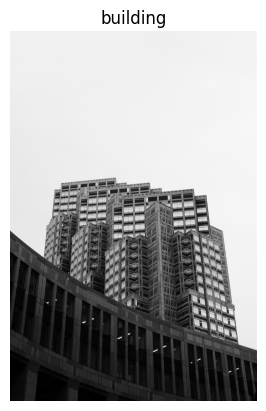

In [42]:
img = cv2.imread("D:/study/OpenCV study/image/building.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 시각화
plt.imshow(img, cmap="gray")
plt.title("building")
plt.axis("off")
plt.show()

## 3. 고급 필터

- `cv2.Sobel`: 엣지 방향까지 얻고 싶을 때 유용    
    - 수평/수직/대각 등 **방향성 엣지 분석**이 필요할 때  
    - Canny 전 단계로 gradient를 보고 싶을 때

In [36]:
# 1. Sobel X, Sobel Y
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)   
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)   

- `Scharr`: Sobel의 특수 케이스, (3x3)의 작은 커널에서 미분 정확도↑, **회전 불변성** 개선   
    - 작은 커널로 **정밀한 미분**이 필요할 때  
    - **Sobel(ksize=3)보다 선명한 엣지**가 필요할 때


In [37]:
# 2. Scharr X, Scharr Y
scharrx = cv2.Scharr(img, cv2.CV_64F, 1, 0)
scharry = cv2.Scharr(img, cv2.CV_64F, 0, 1)

- `cv2.Laplacian`: 이미지의 두 번째 미분, 방향성 없음
    - 방향 불문 **엣지 강도**만 빠르게 보고 싶을 때
    - 제로-크로싱 기반 엣지 감지할 때

In [43]:
# 3. Laplacian
laplacian = cv2.Laplacian(img, cv2.CV_64F)

In [44]:
# 4. Gradient 합성(Sobel)
sobel_combined = cv2.addWeighted(cv2.convertScaleAbs(sobelx), 0.5,
                                 cv2.convertScaleAbs(sobely), 0.5, 0)

## 4. 시각화

In [45]:
titles = ['Original', 'Sobel X', 'Sobel Y', 'Sobel Combined','Scharr X', 'Scharr Y', 'Laplacian']
images = [img, sobelx, sobely, sobel_combined, scharrx, scharry, laplacian]

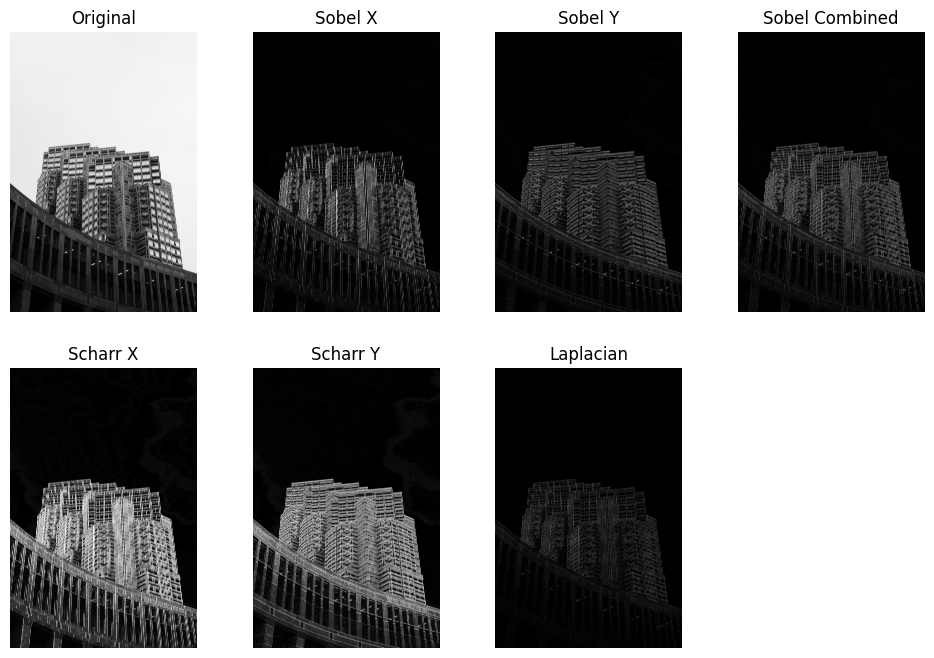

In [46]:
plt.figure(figsize=(12,8))
for i in range(len(images)):
    plt.subplot(2, 4, i+1)
    plt.imshow(cv2.convertScaleAbs(images[i]), cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()

- Sobel X, Scharr X
    - 수직 방향(세로선) 변화에 민감
    - 건물의 세로 프레임, 수직 구조가 잘 보인다.
- Sobel Y, Scharr Y
    - 수평 방향(가로선) 변화에 민감
    - 건물의 가로 프레임, 수평 구조가 잘 보인다.
- Sobel Combined
    - X, Y방향 결과를 합쳐서 전체 윤곽이 선명하다.
- Laplacian 
    - 2차 미분이라 **방향에 관계없이 모든 엣지** 감지